<a href="https://colab.research.google.com/github/padmarajanandhu-code/Case_study_sql/blob/main/housing_database.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.preprocessing import StandardScaler,MinMaxScaler,LabelEncoder


In [5]:
filepath='/content/House_Pricing.csv'
housing_df=pd.read_csv(filepath)
housing_df.head(3)

,ID,Date House was Sold,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Waterfront View,No of Times Visited,...,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
0,7129300520,14 October 2017,221900.0,3,1.00,1180.0,5650.0,1.0,No,NaN,...,7,1180.0,0,63,0,98178.0,47.5112,-122.257,1340.0,5650
1,6414100192,14 December 2017,538000.0,3,2.25,2570.0,7242.0,2.0,No,NaN,...,7,2170.0,400,67,1991,98125.0,47.7210,-122.319,1690.0,7639
2,5631500400,15 February 2016,180000.0,2,1.00,770.0,10000.0,1.0,No,NaN,...,6,770.0,0,85,0,98028.0,47.7379,-122.233,2720.0,8062


In [6]:
housing_df.info()
housing_df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   ID                                         21613 non-null  int64  
 1   Date House was Sold                        21613 non-null  object 
 2   Sale Price                                 21609 non-null  float64
 3   No of Bedrooms                             21613 non-null  int64  
 4   No of Bathrooms                            21609 non-null  float64
 5   Flat Area (in Sqft)                        21604 non-null  float64
 6   Lot Area (in Sqft)                         21604 non-null  float64
 7   No of Floors                               21613 non-null  float64
 8   Waterfront View                            21613 non-null  object 
 9   No of Times Visited                        2124 non-null   object 
 10  Condition of the House

,ID,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
count,2.161300e+04,2.160900e+04,21613.000000,21609.000000,21604.000000,2.160400e+04,21613.000000,21613.000000,21610.000000,21613.000000,21613.000000,21613.000000,21612.000000,21612.000000,21612.000000,21612.000000,21613.000000
mean,4.580302e+09,5.401984e+05,3.370842,2.114732,2079.931772,1.510776e+04,1.494309,7.623467,1788.344193,291.509045,46.994864,84.402258,98077.937766,47.560048,-122.213892,1986.538914,12768.455652
std,2.876566e+09,3.673890e+05,0.930062,0.770138,918.487597,4.142827e+04,0.539989,1.105439,827.982604,442.575043,29.373411,401.679240,53.505425,0.138565,0.140830,685.404255,27304.179631
min,1.000102e+06,7.500000e+04,0.000000,0.000000,290.000000,5.200000e+02,1.000000,1.000000,290.000000,0.000000,3.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000
25%,2.123049e+09,3.219500e+05,3.000000,1.750000,1429.250000,5.040000e+03,1.000000,7.000000,1190.000000,0.000000,21.000000,0.000000,98033.000000,47.470975,-122.328000,1490.000000,5100.000000
50%,3.904930e+09,4.500000e+05,3.000000,2.250000,1910.000000,7.617500e+03,1.500000,7.000000,1560.000000,0.000000,43.000000,0.000000,98065.000000,47.571800,-122.230000,1840.000000,7620.000000
75%,7.308900e+09,6.450000e+05,4.000000,2.500000,2550.000000,1.068825e+04,2.000000,8.000000,2210.000000,560.000000,67.000000,0.000000,98118.000000,47.678000,-122.125000,2360.000000,10083.000000
max,9.900000e+09,7.700000e+06,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,10.000000,9410.000000,4820.000000,118.000000,2015.000000,98199.000000,47.777600,-121.315000,6210.000000,871200.000000


In [7]:
housing_df.isna().sum()

,0
ID,0
Date House was Sold,0
Sale Price,4
No of Bedrooms,0
No of Bathrooms,4
Flat Area (in Sqft),9
Lot Area (in Sqft),9
No of Floors,0
Waterfront View,0
No of Times Visited,19489


In [8]:
housing_df.isnull()

,ID,Date House was Sold,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Waterfront View,No of Times Visited,...,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
0,False,False,False,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21608,False,False,False,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
21609,False,False,False,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
21610,False,False,False,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
21611,False,False,False,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False


In [9]:
missing_percent=housing_df.isna().sum()/len(housing_df)*100
missing_percent.sort_values(ascending=True)

,0
ID,0.000000
Date House was Sold,0.000000
No of Bedrooms,0.000000
No of Floors,0.000000
Basement Area (in Sqft),0.000000
Overall Grade,0.000000
Condition of the House,0.000000
Waterfront View,0.000000
Renovated Year,0.000000
Age of House (in Years),0.000000


In [10]:
num_cols=housing_df.select_dtypes(include=['number'])
cat_cols=housing_df.select_dtypes(include=['object'])


In [11]:
num_cols

,ID,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
0,7129300520,221900.0,3,1.00,1180.0,5650.0,1.0,7,1180.0,0,63,0,98178.0,47.5112,-122.257,1340.0,5650
1,6414100192,538000.0,3,2.25,2570.0,7242.0,2.0,7,2170.0,400,67,1991,98125.0,47.7210,-122.319,1690.0,7639
2,5631500400,180000.0,2,1.00,770.0,10000.0,1.0,6,770.0,0,85,0,98028.0,47.7379,-122.233,2720.0,8062
3,2487200875,604000.0,4,3.00,1960.0,5000.0,1.0,7,1050.0,910,53,0,98136.0,47.5208,-122.393,1360.0,5000
4,1954400510,510000.0,3,2.00,1680.0,8080.0,1.0,8,1680.0,0,31,0,98074.0,47.6168,-122.045,1800.0,7503
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21608,263000018,360000.0,3,2.50,1530.0,1131.0,3.0,8,1530.0,0,9,0,98103.0,47.6993,-122.346,1530.0,1509
21609,6600060120,400000.0,4,2.50,2310.0,5813.0,2.0,8,2310.0,0,4,0,98146.0,47.5107,-122.362,1830.0,7200
21610,1523300141,402101.0,2,0.75,1020.0,1350.0,2.0,7,1020.0,0,9,0,98144.0,47.5944,-122.299,1020.0,2007
21611,291310100,400000.0,3,2.50,1600.0,2388.0,2.0,8,1600.0,0,14,0,98027.0,47.5345,-122.069,1410.0,1287


In [12]:
cat_cols

,Date House was Sold,Waterfront View,No of Times Visited,Condition of the House
0,14 October 2017,No,NaN,Fair
1,14 December 2017,No,NaN,Fair
2,15 February 2016,No,NaN,Fair
3,14 December 2017,No,NaN,Excellent
4,15 February 2016,No,NaN,Fair
...,...,...,...,...
21608,14 May 2017,No,NaN,Fair
21609,15 February 2016,No,NaN,Fair
21610,14 June 2017,No,NaN,Fair
21611,15 January 2016,No,NaN,Fair


In [44]:


num_cols=housing_df.select_dtypes(include=['number']).columns
cat_cols=housing_df.select_dtypes(include=['object']).columns


In [14]:
cat_cols

Index(['Date House was Sold', 'Waterfront View', 'No of Times Visited',
       'Condition of the House'],
      dtype='object')

In [15]:
num_cols

Index(['ID', 'Sale Price', 'No of Bedrooms', 'No of Bathrooms',
       'Flat Area (in Sqft)', 'Lot Area (in Sqft)', 'No of Floors',
       'Overall Grade', 'Area of the House from Basement (in Sqft)',
       'Basement Area (in Sqft)', 'Age of House (in Years)', 'Renovated Year',
       'Zipcode', 'Latitude', 'Longitude',
       'Living Area after Renovation (in Sqft)',
       'Lot Area after Renovation (in Sqft)'],
      dtype='object')

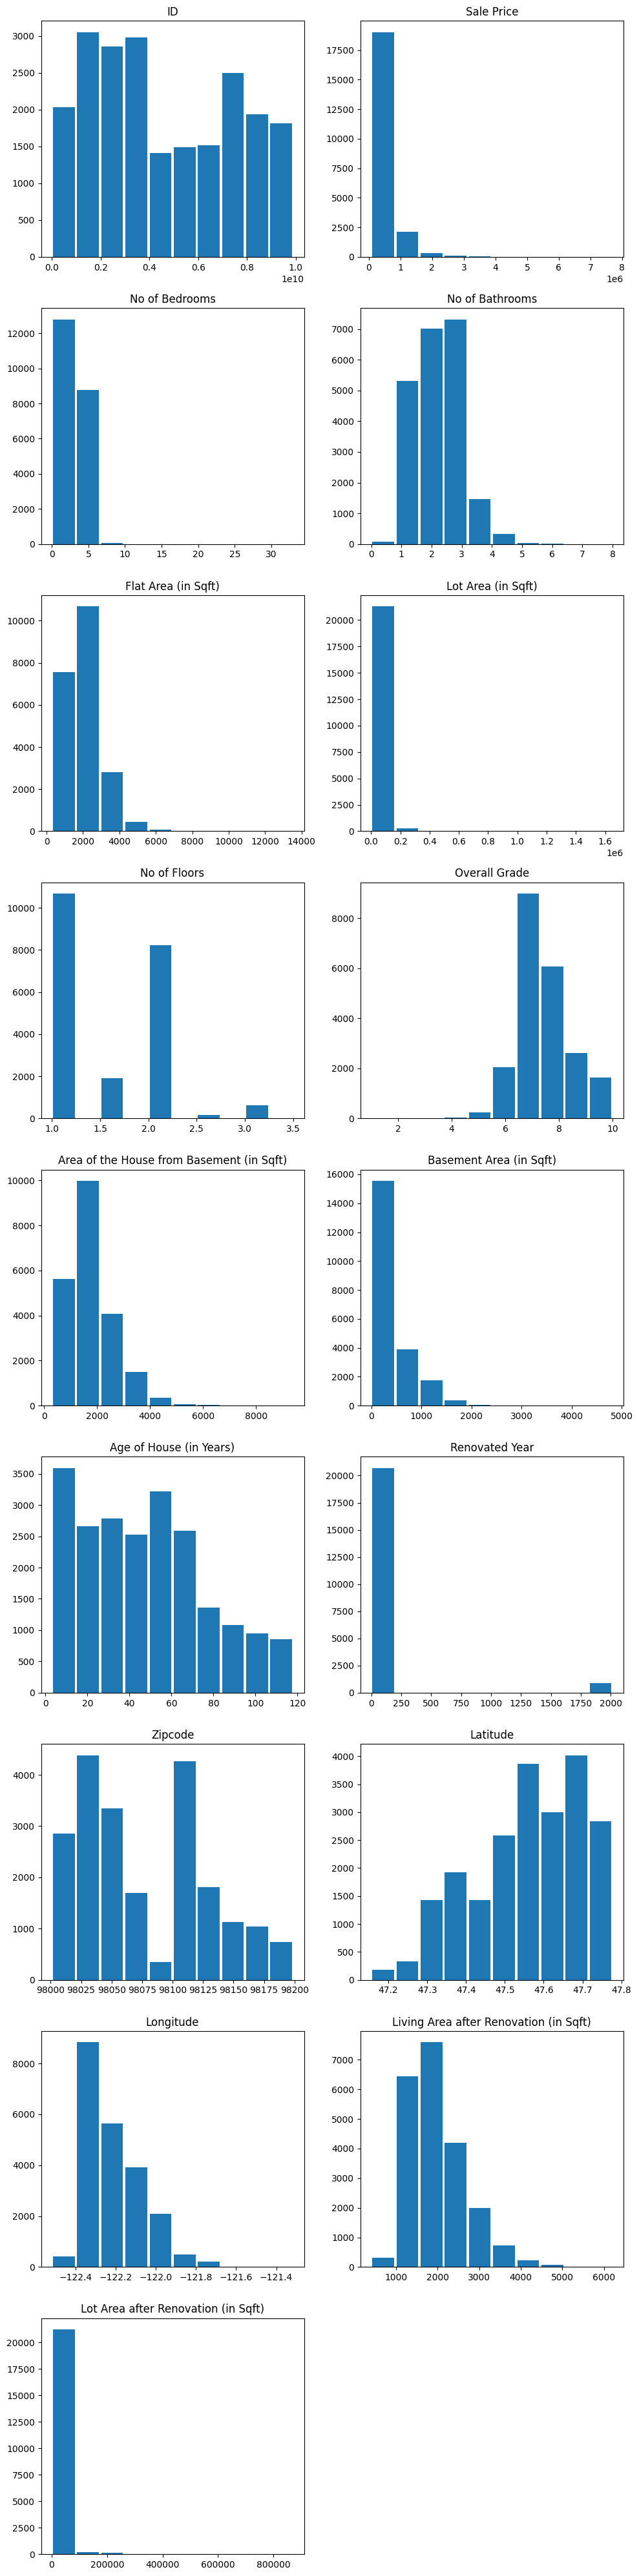

In [16]:
plt.figure(figsize=(10,40))
for i, col in enumerate(num_cols,1):
  plt.subplot(9,2,i)
  plt.hist(housing_df[col],rwidth=0.9)
  plt.title(col)

plt.tight_layout()
plt.show()

In [17]:
num_cols

Index(['ID', 'Sale Price', 'No of Bedrooms', 'No of Bathrooms',
       'Flat Area (in Sqft)', 'Lot Area (in Sqft)', 'No of Floors',
       'Overall Grade', 'Area of the House from Basement (in Sqft)',
       'Basement Area (in Sqft)', 'Age of House (in Years)', 'Renovated Year',
       'Zipcode', 'Latitude', 'Longitude',
       'Living Area after Renovation (in Sqft)',
       'Lot Area after Renovation (in Sqft)'],
      dtype='object')

In [18]:
housing_df.isna().sum()

,0
ID,0
Date House was Sold,0
Sale Price,4
No of Bedrooms,0
No of Bathrooms,4
Flat Area (in Sqft),9
Lot Area (in Sqft),9
No of Floors,0
Waterfront View,0
No of Times Visited,19489


In [19]:
housing_df.shape

(21613, 21)

In [20]:
housing_df['Sale Price'].fillna(housing_df['Sale Price'].median(),inplace=True)
housing_df['Zipcode'].fillna(housing_df['Zipcode'].median(),inplace=True)
housing_df['Latitude'].fillna(housing_df['Latitude'].median(),inplace=True)
housing_df['Longitude'].fillna(housing_df['Longitude'].median(),inplace=True)
housing_df['Flat Area (in Sqft)'].fillna(housing_df['Flat Area (in Sqft)'].median(),inplace=True)
housing_df['No of Bathrooms'].fillna(housing_df['No of Bathrooms'].median(),inplace=True)
housing_df['Lot Area (in Sqft)'].fillna(housing_df['Lot Area (in Sqft)'].median(),inplace=True)
housing_df['Living Area after Renovation (in Sqft)'].fillna(housing_df['Living Area after Renovation (in Sqft)'].median(),inplace=True)
housing_df['Area of the House from Basement (in Sqft)'].fillna(housing_df['Area of the House from Basement (in Sqft)'].median(),inplace=True)
housing_df.isna().sum()

/tmp/ipykernel_1167/696599678.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  housing_df['Sale Price'].fillna(housing_df['Sale Price'].median(),inplace=True)
/tmp/ipykernel_1167/696599678.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].metho

,0
ID,0
Date House was Sold,0
Sale Price,0
No of Bedrooms,0
No of Bathrooms,0
Flat Area (in Sqft),0
Lot Area (in Sqft),0
No of Floors,0
Waterfront View,0
No of Times Visited,19489


In [21]:
housing_df.drop(columns=['No of Times Visited'], inplace=True)

In [22]:
housing_df.isna().sum()

,0
ID,0
Date House was Sold,0
Sale Price,0
No of Bedrooms,0
No of Bathrooms,0
Flat Area (in Sqft),0
Lot Area (in Sqft),0
No of Floors,0
Waterfront View,0
Condition of the House,0


In [23]:
cat_cols

Index(['Date House was Sold', 'Waterfront View', 'No of Times Visited',
       'Condition of the House'],
      dtype='object')

In [24]:
num_cols=housing_df.select_dtypes(include=['number'])
cat_cols=housing_df.select_dtypes(include=['object'])


In [25]:
num_cols

,ID,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
0,7129300520,221900.0,3,1.00,1180.0,5650.0,1.0,7,1180.0,0,63,0,98178.0,47.5112,-122.257,1340.0,5650
1,6414100192,538000.0,3,2.25,2570.0,7242.0,2.0,7,2170.0,400,67,1991,98125.0,47.7210,-122.319,1690.0,7639
2,5631500400,180000.0,2,1.00,770.0,10000.0,1.0,6,770.0,0,85,0,98028.0,47.7379,-122.233,2720.0,8062
3,2487200875,604000.0,4,3.00,1960.0,5000.0,1.0,7,1050.0,910,53,0,98136.0,47.5208,-122.393,1360.0,5000
4,1954400510,510000.0,3,2.00,1680.0,8080.0,1.0,8,1680.0,0,31,0,98074.0,47.6168,-122.045,1800.0,7503
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21608,263000018,360000.0,3,2.50,1530.0,1131.0,3.0,8,1530.0,0,9,0,98103.0,47.6993,-122.346,1530.0,1509
21609,6600060120,400000.0,4,2.50,2310.0,5813.0,2.0,8,2310.0,0,4,0,98146.0,47.5107,-122.362,1830.0,7200
21610,1523300141,402101.0,2,0.75,1020.0,1350.0,2.0,7,1020.0,0,9,0,98144.0,47.5944,-122.299,1020.0,2007
21611,291310100,400000.0,3,2.50,1600.0,2388.0,2.0,8,1600.0,0,14,0,98027.0,47.5345,-122.069,1410.0,1287


In [26]:
num_cols=housing_df.select_dtypes(include=['number']).columns
cat_cols=housing_df.select_dtypes(include=['object']).columns


In [27]:
cat_cols

Index(['Date House was Sold', 'Waterfront View', 'Condition of the House'], dtype='object')

In [28]:
num_cols

Index(['ID', 'Sale Price', 'No of Bedrooms', 'No of Bathrooms',
       'Flat Area (in Sqft)', 'Lot Area (in Sqft)', 'No of Floors',
       'Overall Grade', 'Area of the House from Basement (in Sqft)',
       'Basement Area (in Sqft)', 'Age of House (in Years)', 'Renovated Year',
       'Zipcode', 'Latitude', 'Longitude',
       'Living Area after Renovation (in Sqft)',
       'Lot Area after Renovation (in Sqft)'],
      dtype='object')

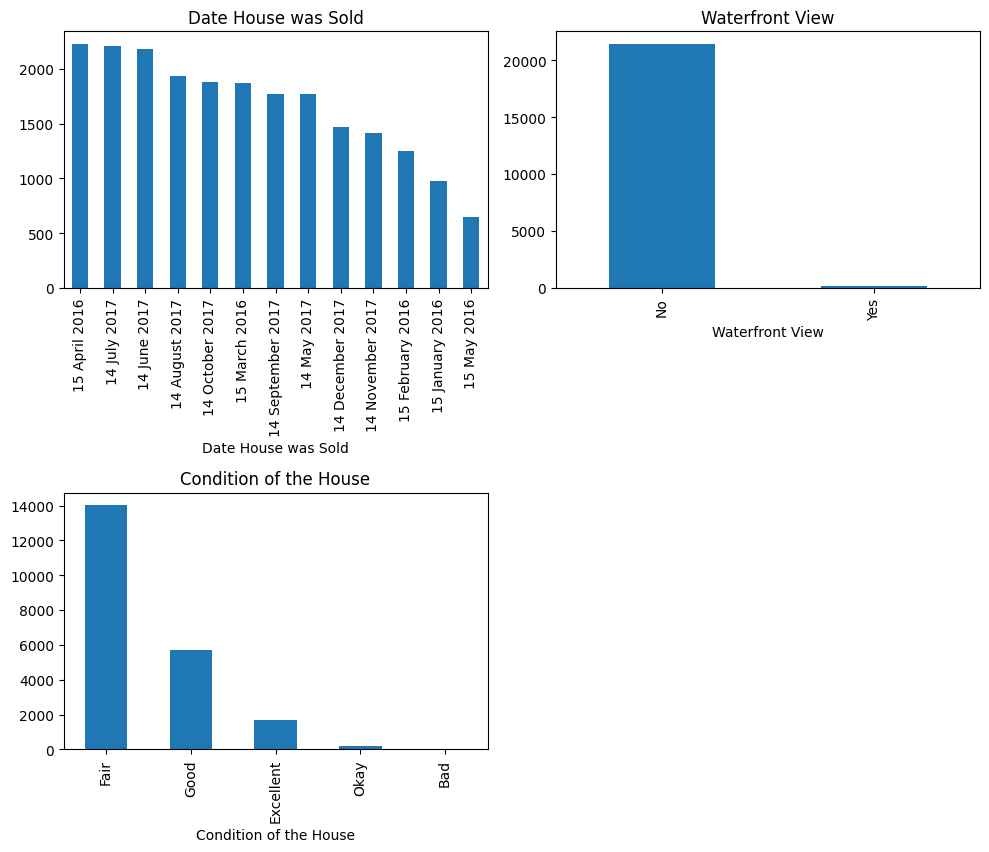

In [29]:
plt.figure(figsize=(10,40))
for i, col in enumerate(cat_cols,1):
  plt.subplot(9,2,i)
  housing_df[col].value_counts().plot(kind='bar')
  plt.title(col)

plt.tight_layout()
plt.show()

In [30]:
housing_df.dropna(axis=0,inplace= True)
housing_df.isna().sum()

,0
ID,0
Date House was Sold,0
Sale Price,0
No of Bedrooms,0
No of Bathrooms,0
Flat Area (in Sqft),0
Lot Area (in Sqft),0
No of Floors,0
Waterfront View,0
Condition of the House,0


#Outlier Handling

In [31]:
housing_df.describe()

,ID,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
count,2.161300e+04,2.161300e+04,21613.000000,21613.000000,21613.000000,2.161300e+04,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000
mean,4.580302e+09,5.401817e+05,3.370842,2.114757,2079.861010,1.510464e+04,1.494309,7.623467,1788.312497,291.509045,46.994864,84.402258,98077.937167,47.560048,-122.213892,1986.532133,12768.455652
std,2.876566e+09,3.673570e+05,0.930062,0.770069,918.302876,4.141992e+04,0.539989,1.105439,827.929506,442.575043,29.373411,401.679240,53.504259,0.138562,0.140827,685.389122,27304.179631
min,1.000102e+06,7.500000e+04,0.000000,0.000000,290.000000,5.200000e+02,1.000000,1.000000,290.000000,0.000000,3.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000
25%,2.123049e+09,3.220000e+05,3.000000,1.750000,1430.000000,5.040000e+03,1.000000,7.000000,1190.000000,0.000000,21.000000,0.000000,98033.000000,47.471000,-122.328000,1490.000000,5100.000000
50%,3.904930e+09,4.500000e+05,3.000000,2.250000,1910.000000,7.617500e+03,1.500000,7.000000,1560.000000,0.000000,43.000000,0.000000,98065.000000,47.571800,-122.230000,1840.000000,7620.000000
75%,7.308900e+09,6.450000e+05,4.000000,2.500000,2550.000000,1.068500e+04,2.000000,8.000000,2210.000000,560.000000,67.000000,0.000000,98118.000000,47.678000,-122.125000,2360.000000,10083.000000
max,9.900000e+09,7.700000e+06,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,10.000000,9410.000000,4820.000000,118.000000,2015.000000,98199.000000,47.777600,-121.315000,6210.000000,871200.000000


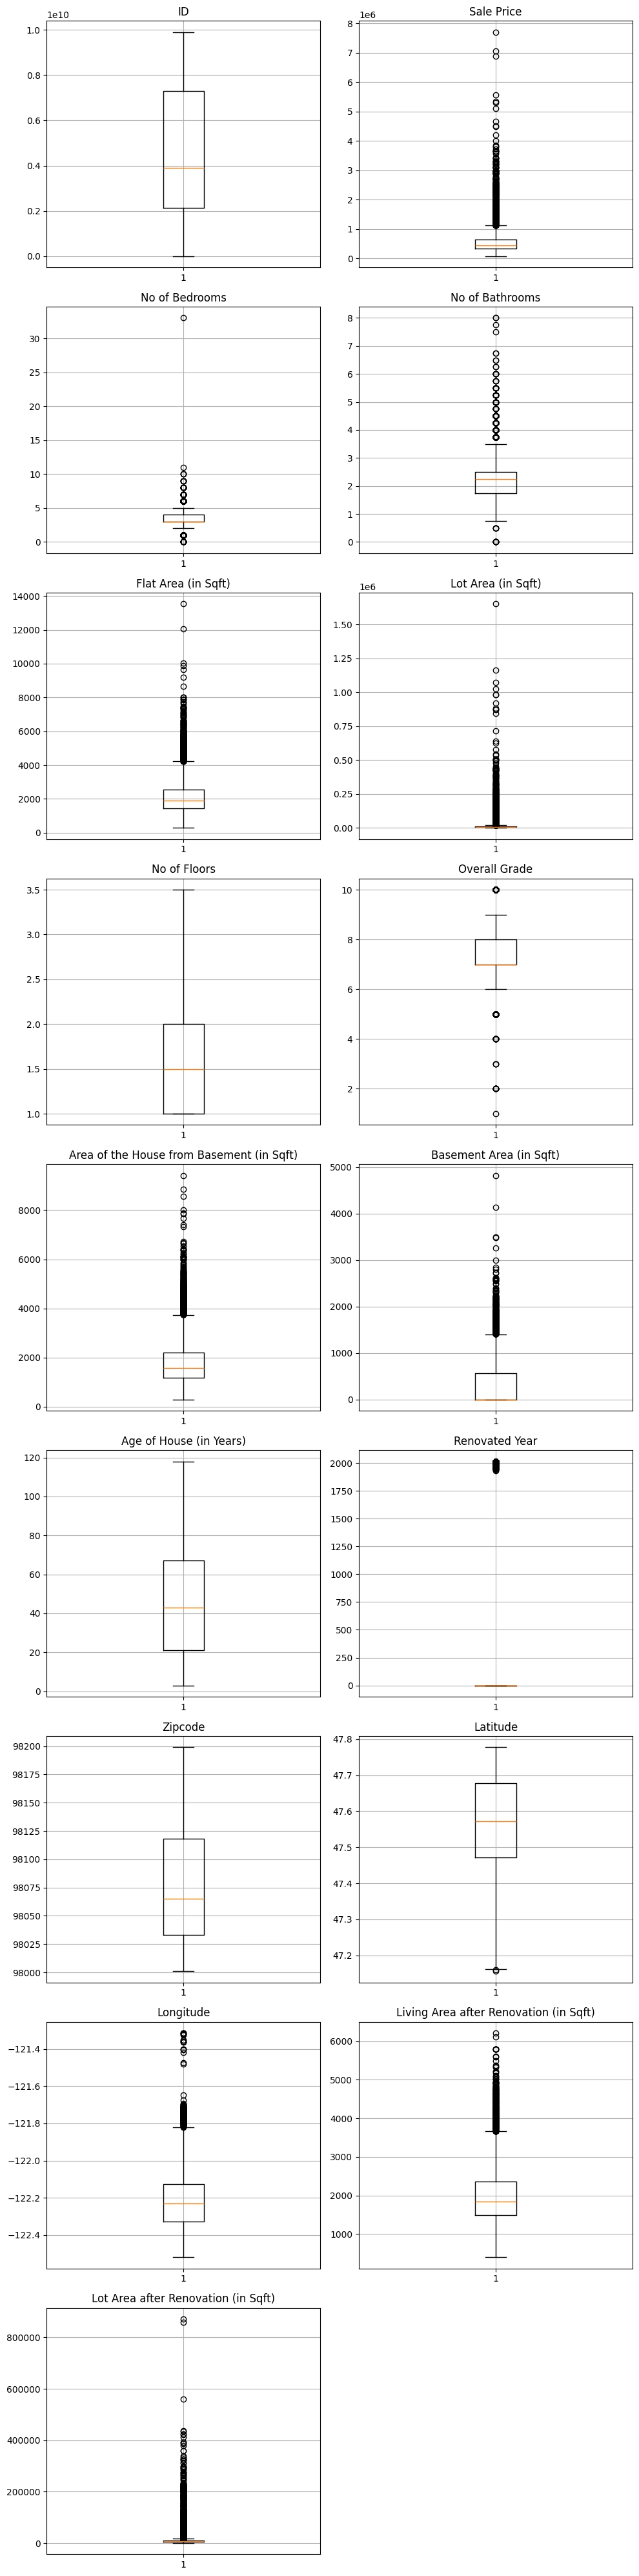

In [32]:
plt.figure(figsize=(10,40))
for i, col in enumerate(num_cols,1):
  plt.subplot(9,2,i)
  plt.boxplot(housing_df[col])
  plt.title(col)
  plt.grid()


plt.tight_layout()
plt.show()

In [33]:
Q1= housing_df[num_cols].quantile(0.25)
Q3= housing_df[num_cols].quantile(0.75)
IQR = Q3-Q1

upper_limit =  (Q3 + 1.5*IQR)
lower_limit = (Q1 - 1.5*IQR)
outliers= ((housing_df[num_cols]> upper_limit) | (housing_df[num_cols]< lower_limit)).any(axis=1)
outliers_df= housing_df[outliers]
outliers_df

,ID,Date House was Sold,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Waterfront View,Condition of the House,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
1,6414100192,14 December 2017,538000.0,3,2.25,2570.0,7242.0,2.0,No,Fair,7,2170.0,400,67,1991,98125.0,47.7210,-122.319,1690.0,7639
5,7237550310,14 May 2017,1230000.0,4,4.50,5420.0,101930.0,1.0,No,Fair,10,3890.0,1530,17,0,98053.0,47.6561,-122.005,4760.0,101930
10,1736800520,15 April 2016,662500.0,3,2.50,3560.0,9796.0,1.0,No,Fair,8,1860.0,1700,53,0,98007.0,47.6007,-122.145,2210.0,8925
12,114101516,14 May 2017,310000.0,3,1.00,1430.0,19901.0,1.5,No,Good,7,1430.0,0,91,0,98028.0,47.7558,-122.229,1780.0,12697
21,2524049179,14 August 2017,2000000.0,3,2.75,3050.0,44867.0,1.0,No,Fair,9,2330.0,720,50,0,98040.0,47.5316,-122.233,4110.0,20336
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21590,7430200100,14 May 2017,1220000.0,4,3.50,4910.0,9444.0,1.5,No,Fair,10,3110.0,1800,11,0,98074.0,47.6502,-122.066,4560.0,11063
21593,8672200110,15 March 2016,1090000.0,5,3.75,4170.0,8142.0,2.0,No,Fair,10,4170.0,0,12,0,98056.0,47.5354,-122.181,3030.0,7980
21597,191100405,15 April 2016,1580000.0,4,3.25,3410.0,10125.0,2.0,No,Fair,10,3410.0,0,11,0,98040.0,47.5653,-122.223,2290.0,10125
21599,7202300110,14 September 2017,810000.0,4,3.00,3990.0,7838.0,2.0,No,Fair,9,3990.0,0,15,0,98053.0,47.6857,-122.046,3370.0,6814


In [35]:
outlier_percentage=len(outliers_df)/len(housing_df)* 100
outlier_percentage

26.43316522463332

In [36]:
housing_df= housing_df[~outliers]
housing_df

,ID,Date House was Sold,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Waterfront View,Condition of the House,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
0,7129300520,14 October 2017,221900.0,3,1.00,1180.0,5650.0,1.0,No,Fair,7,1180.0,0,63,0,98178.0,47.5112,-122.257,1340.0,5650
2,5631500400,15 February 2016,180000.0,2,1.00,770.0,10000.0,1.0,No,Fair,6,770.0,0,85,0,98028.0,47.7379,-122.233,2720.0,8062
3,2487200875,14 December 2017,604000.0,4,3.00,1960.0,5000.0,1.0,No,Excellent,7,1050.0,910,53,0,98136.0,47.5208,-122.393,1360.0,5000
4,1954400510,15 February 2016,510000.0,3,2.00,1680.0,8080.0,1.0,No,Fair,8,1680.0,0,31,0,98074.0,47.6168,-122.045,1800.0,7503
6,1321400060,14 June 2017,257500.0,3,2.25,1715.0,6819.0,2.0,No,Fair,7,1715.0,0,23,0,98003.0,47.3097,-122.327,2238.0,6819
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21608,263000018,14 May 2017,360000.0,3,2.50,1530.0,1131.0,3.0,No,Fair,8,1530.0,0,9,0,98103.0,47.6993,-122.346,1530.0,1509
21609,6600060120,15 February 2016,400000.0,4,2.50,2310.0,5813.0,2.0,No,Fair,8,2310.0,0,4,0,98146.0,47.5107,-122.362,1830.0,7200
21610,1523300141,14 June 2017,402101.0,2,0.75,1020.0,1350.0,2.0,No,Fair,7,1020.0,0,9,0,98144.0,47.5944,-122.299,1020.0,2007
21611,291310100,15 January 2016,400000.0,3,2.50,1600.0,2388.0,2.0,No,Fair,8,1600.0,0,14,0,98027.0,47.5345,-122.069,1410.0,1287


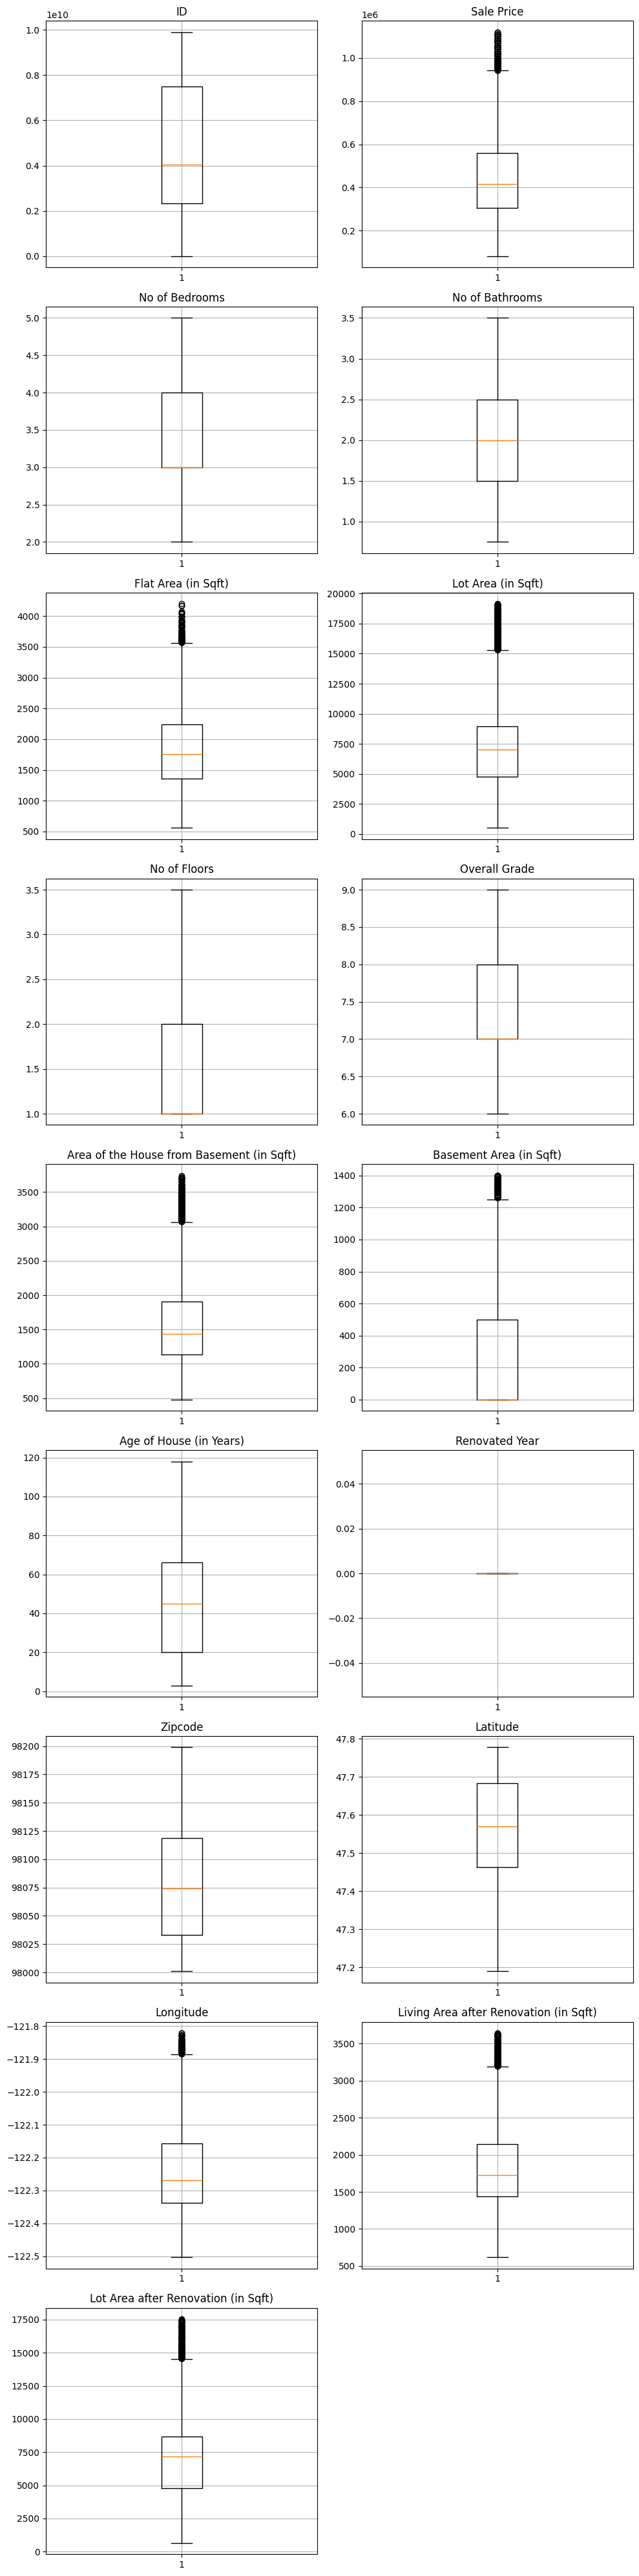

In [40]:
plt.figure(figsize=(10,40))
for i, col in enumerate(num_cols,1):
  plt.subplot(9,2,i)
  plt.boxplot(housing_df[col])
  plt.title(col)
  plt.grid()


plt.tight_layout()
plt.show()

In [41]:
housing_df.drop(columns=['Renovated Year'], inplace=True)

## Duplicates removal

In [42]:
housing_df.duplicated().sum()

np.int64(0)

In [45]:

num_cols=housing_df.select_dtypes(include=['number'])
cat_cols=housing_df.select_dtypes(include=['object'])



In [46]:
num_cols=housing_df.select_dtypes(include=['number']).columns
cat_cols=housing_df.select_dtypes(include=['object']).columns

#Correlation

In [48]:
corr_matrix= housing_df[num_cols].corr(method='pearson')
corr_matrix

,ID,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
ID,1.000000,0.037072,0.007453,0.045949,0.048309,-0.046412,0.033170,0.059330,0.056247,-0.009797,-0.041956,-0.033118,-0.007598,0.074676,0.056262,-0.049815
Sale Price,0.037072,1.000000,0.235779,0.340659,0.521054,-0.069494,0.213942,0.531470,0.399919,0.230763,0.029708,0.016894,0.478372,0.018304,0.464617,-0.075540
No of Bedrooms,0.007453,0.235779,1.000000,0.446127,0.609087,0.207501,0.125569,0.291149,0.479687,0.249782,-0.159461,-0.179120,-0.080549,0.185861,0.405502,0.198259
No of Bathrooms,0.045949,0.340659,0.446127,1.000000,0.670482,-0.072860,0.514540,0.581219,0.590673,0.171823,-0.592271,-0.235135,-0.052971,0.288456,0.503421,-0.075264
Flat Area (in Sqft),0.048309,0.521054,0.609087,0.670482,1.000000,0.177534,0.305943,0.626714,0.821848,0.352774,-0.339393,-0.212158,-0.025078,0.288763,0.719753,0.163812
Lot Area (in Sqft),-0.046412,-0.069494,0.207501,-0.072860,0.177534,1.000000,-0.408294,-0.015734,0.121057,0.103859,0.096948,-0.243135,-0.145757,0.213636,0.217355,0.878023
No of Floors,0.033170,0.213942,0.125569,0.514540,0.305943,-0.408294,1.000000,0.459403,0.518547,-0.331108,-0.544423,-0.066074,0.011742,0.144614,0.231494,-0.413800
Overall Grade,0.059330,0.531470,0.291149,0.581219,0.626714,-0.015734,0.459403,1.000000,0.634336,0.025700,-0.495015,-0.194685,0.059938,0.219749,0.602206,-0.005527
Area of the House from Basement (in Sqft),0.056247,0.399919,0.479687,0.590673,0.821848,0.121057,0.518547,0.634336,1.000000,-0.242562,-0.469569,-0.295472,-0.102811,0.415727,0.687475,0.107546
Basement Area (in Sqft),-0.009797,0.230763,0.249782,0.171823,0.352774,0.103859,-0.331108,0.025700,-0.242562,1.000000,0.193824,0.124118,0.126179,-0.191407,0.097217,0.102744


<Axes: >

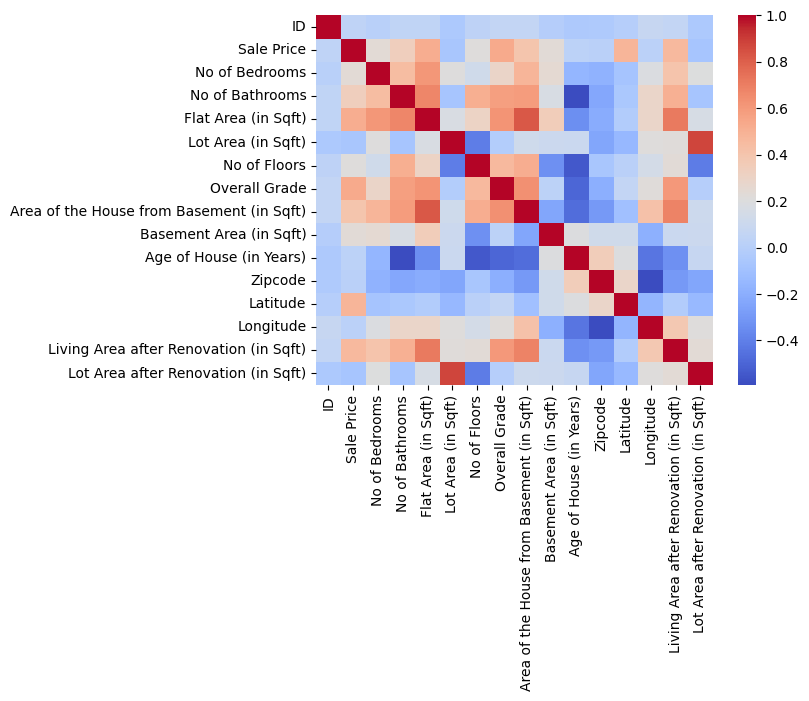

In [49]:
sns.heatmap(corr_matrix, cmap='coolwarm')

In [50]:
housing_df.drop(['ID','Zipcode','Latitude','Longitude'], axis=1,inplace= True)
housing_df.head(5)

,Date House was Sold,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Waterfront View,Condition of the House,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
0,14 October 2017,221900.0,3,1.00,1180.0,5650.0,1.0,No,Fair,7,1180.0,0,63,1340.0,5650
2,15 February 2016,180000.0,2,1.00,770.0,10000.0,1.0,No,Fair,6,770.0,0,85,2720.0,8062
3,14 December 2017,604000.0,4,3.00,1960.0,5000.0,1.0,No,Excellent,7,1050.0,910,53,1360.0,5000
4,15 February 2016,510000.0,3,2.00,1680.0,8080.0,1.0,No,Fair,8,1680.0,0,31,1800.0,7503
6,14 June 2017,257500.0,3,2.25,1715.0,6819.0,2.0,No,Fair,7,1715.0,0,23,2238.0,6819


In [51]:
num_cols= housing_df.select_dtypes(include=['number']).columns
num_cols

Index(['Sale Price', 'No of Bedrooms', 'No of Bathrooms',
       'Flat Area (in Sqft)', 'Lot Area (in Sqft)', 'No of Floors',
       'Overall Grade', 'Area of the House from Basement (in Sqft)',
       'Basement Area (in Sqft)', 'Age of House (in Years)',
       'Living Area after Renovation (in Sqft)',
       'Lot Area after Renovation (in Sqft)'],
      dtype='object')

In [53]:
housing_df.head(5)

,Date House was Sold,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Waterfront View,Condition of the House,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
0,14 October 2017,221900.0,3,1.00,1180.0,5650.0,1.0,No,Fair,7,1180.0,0,63,1340.0,5650
2,15 February 2016,180000.0,2,1.00,770.0,10000.0,1.0,No,Fair,6,770.0,0,85,2720.0,8062
3,14 December 2017,604000.0,4,3.00,1960.0,5000.0,1.0,No,Excellent,7,1050.0,910,53,1360.0,5000
4,15 February 2016,510000.0,3,2.00,1680.0,8080.0,1.0,No,Fair,8,1680.0,0,31,1800.0,7503
6,14 June 2017,257500.0,3,2.25,1715.0,6819.0,2.0,No,Fair,7,1715.0,0,23,2238.0,6819


#Data Transforming

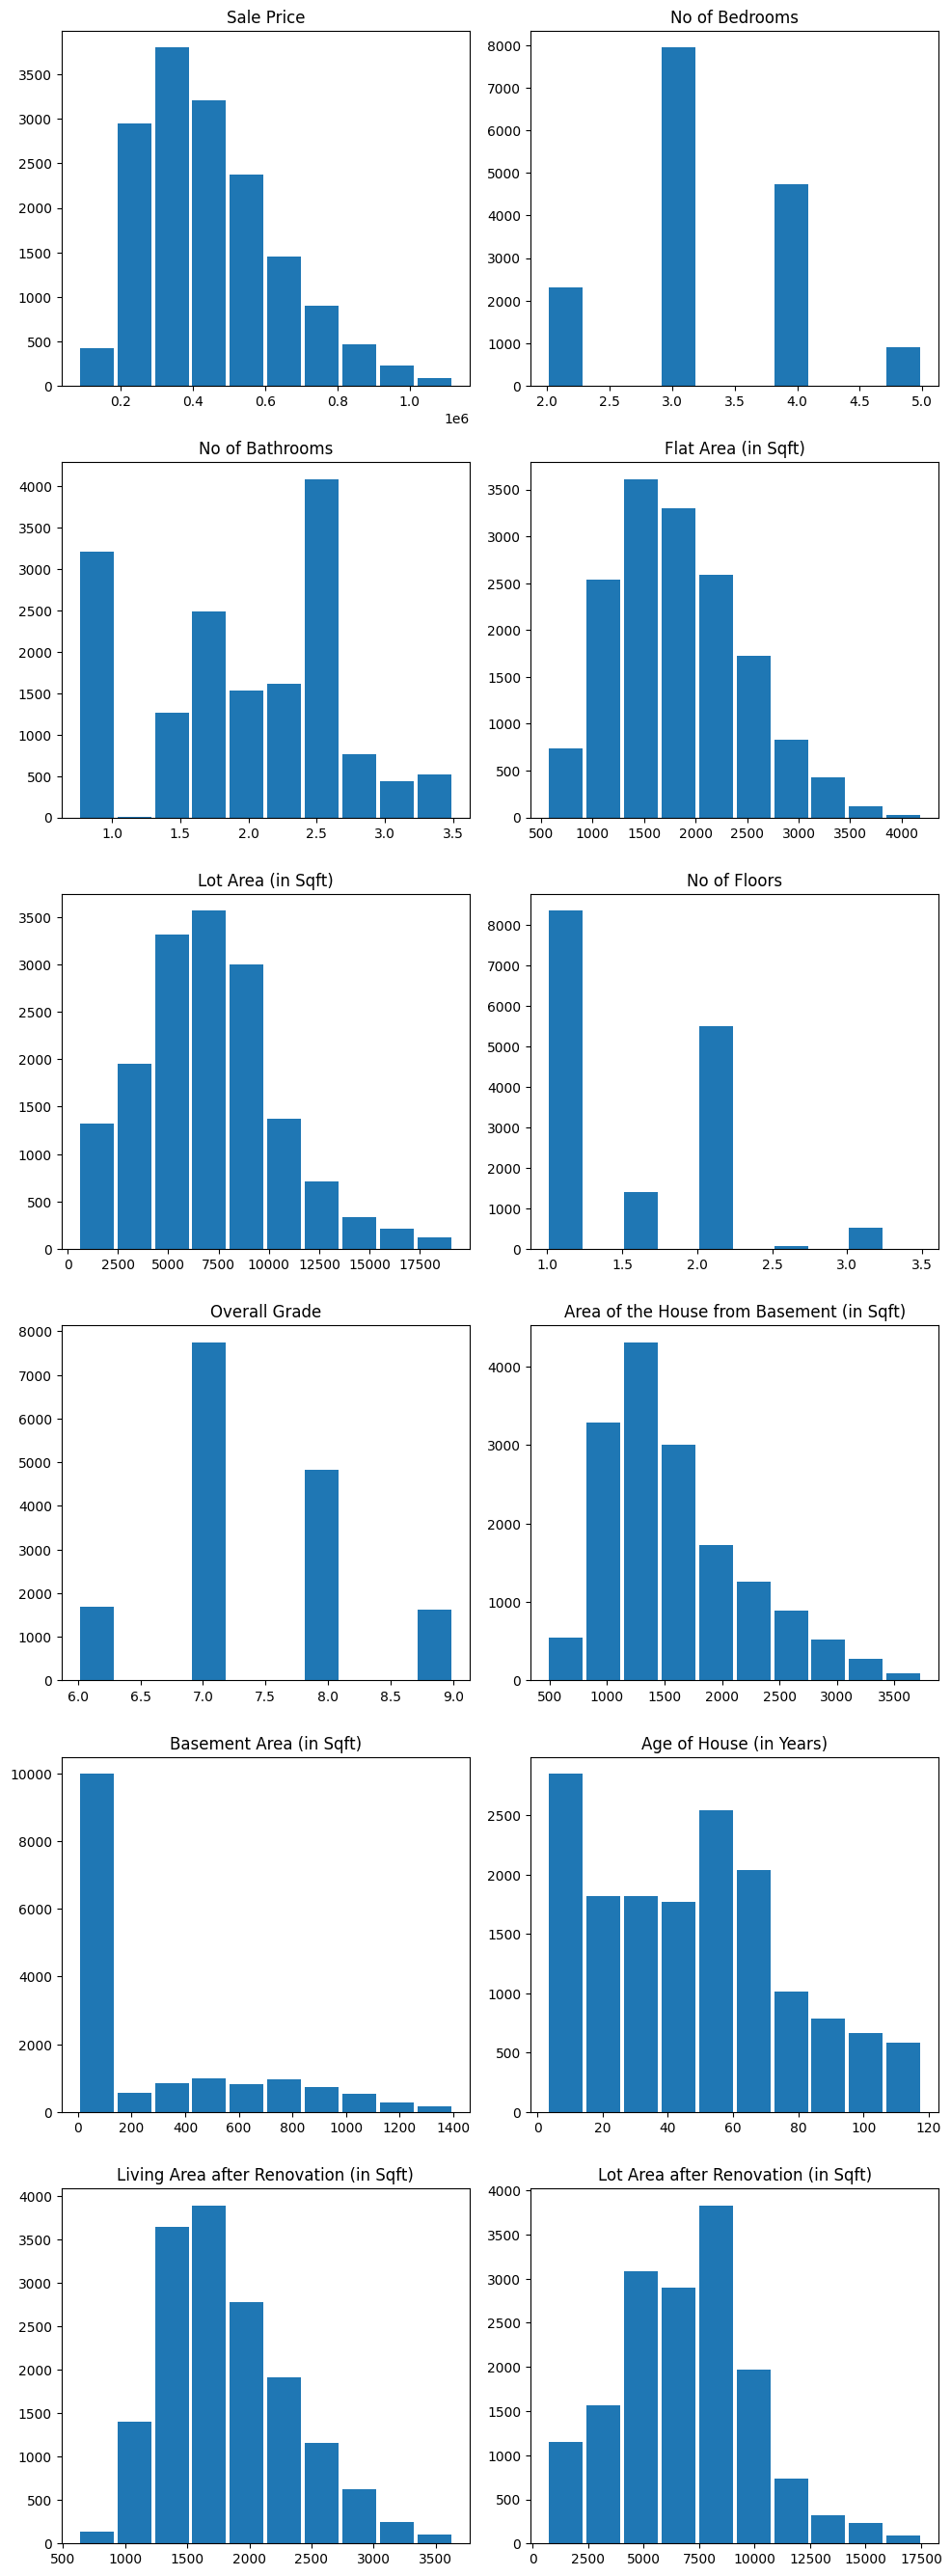

In [56]:
plt.figure(figsize=(10,40))
for i, col in enumerate(num_cols,1):
  plt.subplot(9,2,i)
  plt.hist(housing_df[col],rwidth=0.9)
  plt.title(col)

plt.tight_layout()
plt.show()

In [57]:
num_cols

Index(['Sale Price', 'No of Bedrooms', 'No of Bathrooms',
       'Flat Area (in Sqft)', 'Lot Area (in Sqft)', 'No of Floors',
       'Overall Grade', 'Area of the House from Basement (in Sqft)',
       'Basement Area (in Sqft)', 'Age of House (in Years)',
       'Living Area after Renovation (in Sqft)',
       'Lot Area after Renovation (in Sqft)'],
      dtype='object')

In [58]:
housing_df.describe()

,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
count,1.590000e+04,15900.000000,15900.000000,15900.000000,15900.000000,15900.000000,15900.000000,15900.000000,15900.000000,15900.000000,15900.000000,15900.000000
mean,4.487819e+05,3.267736,1.981179,1834.896164,7030.641824,1.466069,7.402390,1588.989245,245.917421,46.947170,1819.767862,6907.478365
std,1.862429e+05,0.775808,0.648012,621.912206,3375.398004,0.546501,0.811713,600.028235,364.970250,29.289552,515.255245,3005.880095
min,8.200000e+04,2.000000,0.750000,560.000000,520.000000,1.000000,6.000000,480.000000,0.000000,3.000000,620.000000,651.000000
25%,3.050000e+05,3.000000,1.500000,1360.000000,4749.500000,1.000000,7.000000,1140.000000,0.000000,20.000000,1440.000000,4800.000000
50%,4.150000e+05,3.000000,2.000000,1760.000000,7027.500000,1.000000,7.000000,1440.000000,0.000000,45.000000,1730.000000,7165.000000
75%,5.600000e+05,4.000000,2.500000,2240.000000,8977.750000,2.000000,8.000000,1910.000000,500.000000,66.000000,2140.000000,8700.000000
max,1.120000e+06,5.000000,3.500000,4200.000000,19141.000000,3.500000,9.000000,3740.000000,1400.000000,118.000000,3640.000000,17550.000000


In [59]:
min_max_scaler= MinMaxScaler()
housing_df[['No of Bedrooms', 'No of Bathrooms',
       'Flat Area (in Sqft)', 'Lot Area (in Sqft)', 'No of Floors',
       'Overall Grade', 'Area of the House from Basement (in Sqft)',
       'Basement Area (in Sqft)', 'Age of House (in Years)',
       'Living Area after Renovation (in Sqft)',
       'Lot Area after Renovation (in Sqft)']]= min_max_scaler.fit_transform(housing_df[['No of Bedrooms', 'No of Bathrooms',
       'Flat Area (in Sqft)', 'Lot Area (in Sqft)', 'No of Floors',
       'Overall Grade', 'Area of the House from Basement (in Sqft)',
       'Basement Area (in Sqft)', 'Age of House (in Years)',
       'Living Area after Renovation (in Sqft)',
       'Lot Area after Renovation (in Sqft)']])

In [60]:
housing_df.describe()

,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
count,1.590000e+04,15900.000000,15900.000000,15900.000000,15900.000000,15900.000000,15900.000000,15900.000000,15900.000000,15900.000000,15900.000000,15900.000000
mean,4.487819e+05,0.422579,0.447702,0.350246,0.349640,0.186428,0.467463,0.340181,0.175655,0.382149,0.397274,0.370228
std,1.862429e+05,0.258603,0.235641,0.170855,0.181268,0.218600,0.270571,0.184058,0.260693,0.254692,0.170614,0.177873
min,8.200000e+04,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.050000e+05,0.333333,0.272727,0.219780,0.227136,0.000000,0.333333,0.202454,0.000000,0.147826,0.271523,0.245517
50%,4.150000e+05,0.333333,0.454545,0.329670,0.349471,0.000000,0.333333,0.294479,0.000000,0.365217,0.367550,0.385467
75%,5.600000e+05,0.666667,0.636364,0.461538,0.454205,0.400000,0.666667,0.438650,0.357143,0.547826,0.503311,0.476300
max,1.120000e+06,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


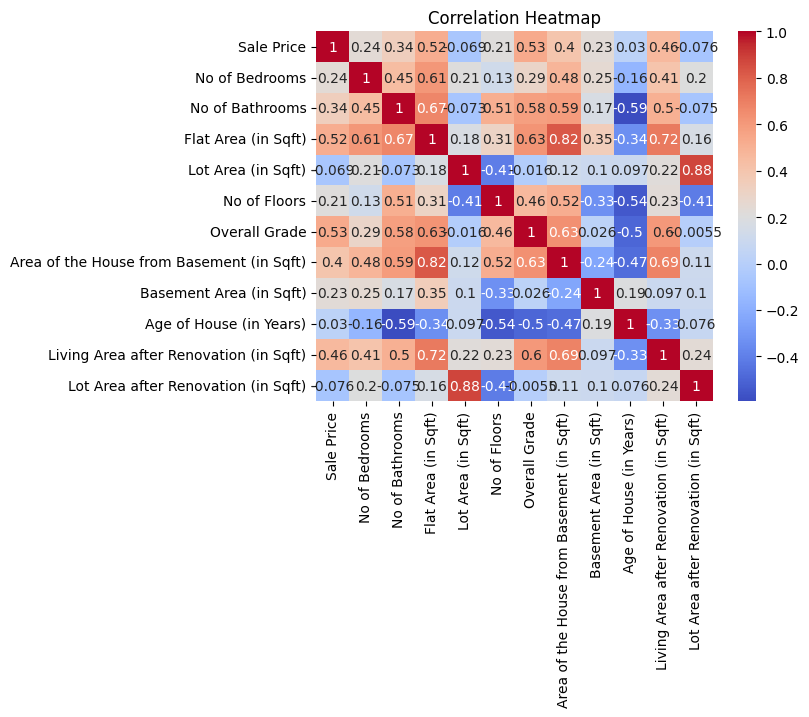

In [61]:
corr_matrix= housing_df[num_cols].corr(method='pearson')
corr_matrix

sns.heatmap(corr_matrix,annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [62]:
housing_df.head(2)

,Date House was Sold,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Waterfront View,Condition of the House,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
0,14 October 2017,221900.0,0.333333,0.090909,0.170330,0.275495,0.0,No,Fair,0.333333,0.214724,0.0,0.521739,0.238411,0.295816
2,15 February 2016,180000.0,0.000000,0.090909,0.057692,0.509103,0.0,No,Fair,0.000000,0.088957,0.0,0.713043,0.695364,0.438547


#Data Encoding

In [63]:
cat_cols

Index(['Date House was Sold', 'Waterfront View', 'Condition of the House'], dtype='object')

In [64]:
unique_values = housing_df['Waterfront View'].unique()
print(unique_values)

['No' 'Yes']


In [65]:
unique_values = housing_df['Condition of the House'].unique()
print(unique_values)

['Fair' 'Excellent' 'Good' 'Okay' 'Bad']


In [66]:
label_encoder= LabelEncoder()
housing_df['Waterfront View']=label_encoder.fit_transform(housing_df['Waterfront View'])
housing_df['Condition of the House']=label_encoder.fit_transform(housing_df['Condition of the House'])

In [67]:

housing_df.head(10)

,Date House was Sold,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Waterfront View,Condition of the House,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
0,14 October 2017,221900.0,0.333333,0.090909,0.170330,0.275495,0.0,0,2,0.333333,0.214724,0.000000,0.521739,0.238411,0.295816
2,15 February 2016,180000.0,0.000000,0.090909,0.057692,0.509103,0.0,0,2,0.000000,0.088957,0.000000,0.713043,0.695364,0.438547
3,14 December 2017,604000.0,0.666667,0.818182,0.384615,0.240589,0.0,0,1,0.333333,0.174847,0.650000,0.434783,0.245033,0.257353
4,15 February 2016,510000.0,0.333333,0.454545,0.307692,0.405993,0.0,0,2,0.666667,0.368098,0.000000,0.243478,0.390728,0.405468
6,14 June 2017,257500.0,0.333333,0.545455,0.317308,0.338274,0.4,0,2,0.333333,0.378834,0.000000,0.173913,0.535762,0.364992
7,15 January 2016,291850.0,0.333333,0.272727,0.137363,0.493583,0.0,0,2,0.333333,0.177914,0.000000,0.452174,0.341060,0.536126
8,15 April 2016,229500.0,0.333333,0.090909,0.335165,0.373235,0.0,0,2,0.333333,0.174847,0.521429,0.478261,0.384106,0.441565
9,15 March 2016,323000.0,0.333333,0.636364,0.365385,0.324365,0.4,0,2,0.333333,0.432515,0.000000,0.104348,0.586093,0.409433
11,14 May 2017,468000.0,0.000000,0.090909,0.164835,0.294291,0.0,0,3,0.333333,0.116564,0.214286,0.634783,0.235099,0.316528
13,14 October 2017,400000.0,0.333333,0.363636,0.222527,0.491918,0.0,0,3,0.333333,0.273006,0.000000,0.330435,0.248344,0.565536


In [68]:
unique_values = housing_df['Waterfront View'].unique()
print(unique_values)

[0 1]


In [69]:
unique_values = housing_df['Condition of the House'].unique()
print(unique_values)

[2 1 3 4 0]


In [71]:
mapping = {
    0: "Poor",
    1: "Fair",
    2: "Average",
    3: "Good",
    4: "Excellent"
}

housing_df['Condition of the House'] = housing_df['Condition of the House'].map(mapping)

In [72]:
unique_values = housing_df['Condition of the House'].unique()
print(unique_values)

['Average' 'Fair' 'Good' 'Excellent' 'Poor']


In [73]:
housing_df.head(10)

,Date House was Sold,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Waterfront View,Condition of the House,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
0,14 October 2017,221900.0,0.333333,0.090909,0.170330,0.275495,0.0,0,Average,0.333333,0.214724,0.000000,0.521739,0.238411,0.295816
2,15 February 2016,180000.0,0.000000,0.090909,0.057692,0.509103,0.0,0,Average,0.000000,0.088957,0.000000,0.713043,0.695364,0.438547
3,14 December 2017,604000.0,0.666667,0.818182,0.384615,0.240589,0.0,0,Fair,0.333333,0.174847,0.650000,0.434783,0.245033,0.257353
4,15 February 2016,510000.0,0.333333,0.454545,0.307692,0.405993,0.0,0,Average,0.666667,0.368098,0.000000,0.243478,0.390728,0.405468
6,14 June 2017,257500.0,0.333333,0.545455,0.317308,0.338274,0.4,0,Average,0.333333,0.378834,0.000000,0.173913,0.535762,0.364992
7,15 January 2016,291850.0,0.333333,0.272727,0.137363,0.493583,0.0,0,Average,0.333333,0.177914,0.000000,0.452174,0.341060,0.536126
8,15 April 2016,229500.0,0.333333,0.090909,0.335165,0.373235,0.0,0,Average,0.333333,0.174847,0.521429,0.478261,0.384106,0.441565
9,15 March 2016,323000.0,0.333333,0.636364,0.365385,0.324365,0.4,0,Average,0.333333,0.432515,0.000000,0.104348,0.586093,0.409433
11,14 May 2017,468000.0,0.000000,0.090909,0.164835,0.294291,0.0,0,Good,0.333333,0.116564,0.214286,0.634783,0.235099,0.316528
13,14 October 2017,400000.0,0.333333,0.363636,0.222527,0.491918,0.0,0,Good,0.333333,0.273006,0.000000,0.330435,0.248344,0.565536


In [75]:
mapping = {
    "Poor": 0,
    "Fair": 1,
    "Average": 2,
    "Good": 3,
    "Excellent": 4
}

housing_df['Condition of the House'] = housing_df['Condition of the House'].map(mapping)

In [76]:
unique_values = housing_df['Condition of the House'].unique()
print(unique_values)

[2 1 3 4 0]


In [77]:
housing_df.head(10)

,Date House was Sold,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Waterfront View,Condition of the House,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
0,14 October 2017,221900.0,0.333333,0.090909,0.170330,0.275495,0.0,0,2,0.333333,0.214724,0.000000,0.521739,0.238411,0.295816
2,15 February 2016,180000.0,0.000000,0.090909,0.057692,0.509103,0.0,0,2,0.000000,0.088957,0.000000,0.713043,0.695364,0.438547
3,14 December 2017,604000.0,0.666667,0.818182,0.384615,0.240589,0.0,0,1,0.333333,0.174847,0.650000,0.434783,0.245033,0.257353
4,15 February 2016,510000.0,0.333333,0.454545,0.307692,0.405993,0.0,0,2,0.666667,0.368098,0.000000,0.243478,0.390728,0.405468
6,14 June 2017,257500.0,0.333333,0.545455,0.317308,0.338274,0.4,0,2,0.333333,0.378834,0.000000,0.173913,0.535762,0.364992
7,15 January 2016,291850.0,0.333333,0.272727,0.137363,0.493583,0.0,0,2,0.333333,0.177914,0.000000,0.452174,0.341060,0.536126
8,15 April 2016,229500.0,0.333333,0.090909,0.335165,0.373235,0.0,0,2,0.333333,0.174847,0.521429,0.478261,0.384106,0.441565
9,15 March 2016,323000.0,0.333333,0.636364,0.365385,0.324365,0.4,0,2,0.333333,0.432515,0.000000,0.104348,0.586093,0.409433
11,14 May 2017,468000.0,0.000000,0.090909,0.164835,0.294291,0.0,0,3,0.333333,0.116564,0.214286,0.634783,0.235099,0.316528
13,14 October 2017,400000.0,0.333333,0.363636,0.222527,0.491918,0.0,0,3,0.333333,0.273006,0.000000,0.330435,0.248344,0.565536
